# ECOS — Block 2: Evolution across Freeze-Thaw Cycles

**Objective:** Analyze how $C_l$, density, and thickness evolve as phantoms undergo
successive freeze-thaw cycles. Since the same pieces are measured at every cycle,
this is a **repeated-measures** analysis — the most powerful design available,
because each specimen acts as its own control.

**Hypotheses tested:** H3 (cycles increase $C_l$), H5 (convergence) — *Study Rules §1*.

**Key questions:**
- Do properties change significantly between cycles?
- Do they converge (saturate) or keep changing?
- Does the rate of change depend on composition (PVA%, PG%)?
- How many cycles are needed for stable phantoms?

> **Important:** Changes between cycles may reflect cross-linking, water loss/absorption,
> PG migration, or aging. These cannot be separated with current data — acknowledge this
> limitation in all interpretations.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats
from IPython.display import display

sys.path.insert(0, str(Path().resolve()))
import ecos_loader

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

base_dir = Path('../database')
df = ecos_loader.build_catalog(base_dir)

for col in ('pva_pct', 'pg_pct', 'cycle'):
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['pva_real'] = df['pva_pct'].apply(lambda x: x / 10 if x > 100 else x)

fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)

# Color convention (Study Rules §7): tab10, consistent with Block 1
_cmap         = plt.cm.tab10
PVA_LEVELS    = sorted(df['pva_real'].dropna().unique())
PG_LEVELS     = sorted(df['pg_pct'].dropna().unique())
PVA_COLOR     = {pva: _cmap(i) for i, pva in enumerate(PVA_LEVELS)}
PG_COLOR      = {pg:  _cmap(i) for i, pg  in enumerate(PG_LEVELS)}
PG_MARKER     = {pg: m for pg, m in zip(PG_LEVELS, ['o', 's', '^', 'D'])}
PG_LINESTYLE  = {pg: ls for pg, ls in zip(PG_LEVELS, ['-', '--', ':', '-.'])}
PVA_LINESTYLE = {pva: ls for pva, ls in zip(PVA_LEVELS, ['-', '--', ':'])}

cycles_avail = sorted(df['cycle'].dropna().unique())
print(f'Catalog shape: {df.shape}')
print(f'Cycles: {[int(c) for c in cycles_avail]}')
print(f'PVA levels: {PVA_LEVELS}')
print(f'PG levels:  {PG_LEVELS}')


[scan_database] loaded 180 US, 180 DENS
Catalog shape: (180, 26)
Cycles: [3, 4, 5]
PVA levels: [np.float64(10.0), np.float64(12.5), np.float64(15.0)]
PG levels:  [np.int64(0), np.int64(5), np.int64(10), np.int64(15)]


In [ ]:
# ============================================================
# DENSITY SETTINGS — adjust these values before running
# ============================================================
DENSITY_MODE = "calibrated"  # "measured" | "calibrated"
R_MODE       = "auto"        # "auto" (95th percentile) | "manual"
R_MANUAL_CM  = 8.95          # used only if R_MODE = "manual"
# ============================================================

import numpy as np
from scipy.optimize import brentq

def calibrate_radius(df, percentile=0.95):
    """Find vessel radius r such that (percentile)% of density values > 1.0."""
    mask = df["DENS_delta_h_cm"].notna() & df["DENS_mass_g"].notna()
    dh   = df.loc[mask, "DENS_delta_h_cm"].values
    mass = df.loc[mask, "DENS_mass_g"].values

    def pct_above(r):
        return np.mean(mass / (np.pi * r**2 * dh) > 1.0) - percentile

    try:
        return brentq(pct_above, 5.0, 15.0)
    except ValueError:
        print("[WARNING] Could not calibrate radius — check data range")
        return df["DENS_r_vessel_cm"].dropna().iloc[0]

def apply_density_mode(df, mode, r_mode, r_manual):
    """Recalculate DENS_density_gcm3 according to selected mode."""
    mask = df["DENS_delta_h_cm"].notna() & df["DENS_mass_g"].notna()

    if mode == "measured":
        print(f"[density] Using measured density values (original JSON)")
        return df

    # mode == "calibrated"
    if r_mode == "manual":
        r = r_manual
        print(f"[density] Calibrated mode — manual radius: {r:.4f} cm")
    else:
        r = calibrate_radius(df)
        print(f"[density] Calibrated mode — auto radius (95th pct): {r:.4f} cm")
        print(f"          Original radius: {df['DENS_r_vessel_cm'].dropna().iloc[0]:.4f} cm")

    df = df.copy()
    df.loc[mask, "DENS_density_gcm3"] = (
        df.loc[mask, "DENS_mass_g"] /
        (np.pi * r**2 * df.loc[mask, "DENS_delta_h_cm"])
    )
    pct_above = (df.loc[mask, "DENS_density_gcm3"] > 1.0).mean() * 100
    print(f"          {pct_above:.1f}% of specimens with density > 1.0 g/cm³")
    return df

# Apply
df = apply_density_mode(df, DENSITY_MODE, R_MODE, R_MANUAL_CM)
print(f"\nDensity stats after mode '{DENSITY_MODE}':")
print(df.groupby(['pva_real','pg_pct'])['DENS_density_gcm3']
        .agg(['mean','std']).round(4))

---
## Cell 2.0 — Cycle overview

Bookkeeping before any analysis: which pieces are measured at which cycles.
Missing measurements affect all paired analyses (incomplete pairs are dropped).

**Red flags:** any cell = 0 (missing measurement); unequal n across cycles.

In [2]:
# --- Cell 2.0: Cycle overview and availability ---
print('Specimens per cycle:')
cycle_summary = df.groupby('cycle').agg(
    n_specimens=('US_Cl', 'count'),
    n_with_density=('DENS_density_gcm3', 'count'),
    n_conditions=('pva_real', lambda x: x.dropna().nunique()),
    Cl_mean=('US_Cl', 'mean'),
    Cl_std=('US_Cl', 'std'),
).round(2)
cycle_summary.index = [int(c) for c in cycle_summary.index]
cycle_summary.index.name = 'Cycle'
display(cycle_summary)

# Availability matrix: was each piece measured at each cycle?
print('\nAvailability matrix (US_Cl): rows=(PVA, PG, piece), columns=cycle')
avail = df.pivot_table(
    index=['pva_real', 'pg_pct', 'piece'],
    columns='cycle',
    values='US_Cl',
    aggfunc='count'
).fillna(0).astype(int)
avail.columns = [int(c) for c in avail.columns]
avail.columns.name = 'Cycle'
display(avail)

missing = (avail == 0).sum().sum()
if missing:
    print(f'\n[!] {missing} missing measurement(s) detected — paired analyses will drop incomplete rows.')
else:
    print('\nAll pieces present at all cycles.')


Specimens per cycle:


,n_specimens,n_with_density,n_conditions,Cl_mean,Cl_std
Cycle,,,,,
3,60,60,3,1619.60,9.01
4,60,60,3,1604.60,7.87
5,60,60,3,1603.59,11.61



Availability matrix (US_Cl): rows=(PVA, PG, piece), columns=cycle


Cycle                  3  4  5
pva_real pg_pct piece         
10.0     0      A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         5      A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         10     A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         15     A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
12.5     0      A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         5      A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         10     A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         15     A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
15.0     0      A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         5      A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         10     A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1
         15     A      1  1  1
                B      1  1  1
                C      1  1  1
                D      1  1  1
                E      1  1  1


All pieces present at all cycles.


---
## Block 2 data preparation

Pivot tables and delta DataFrames used by cells 2.4–2.10.
**Run this cell before any analysis cell.**

In [3]:
# --- Block 2: pivot tables and delta DataFrames ---
sorted_cycles = sorted(df['cycle'].dropna().unique())
transitions   = [(c1, c2) for c1, c2 in zip(sorted_cycles[:-1], sorted_cycles[1:])]
print(f'Cycles: {[int(c) for c in sorted_cycles]}')
print(f'Transitions: {[(int(c1), int(c2)) for c1, c2 in transitions]}')

# Pivot: rows = (pva_real, pg_pct, piece), columns = cycle value
pivot_cl = df.pivot_table(
    index=['pva_real', 'pg_pct', 'piece'],
    columns='cycle', values='US_Cl', aggfunc='mean'
)
pivot_dens = df.pivot_table(
    index=['pva_real', 'pg_pct', 'piece'],
    columns='cycle', values='DENS_density_gcm3', aggfunc='mean'
)
pivot_d = df.pivot_table(
    index=['pva_real', 'pg_pct', 'piece'],
    columns='cycle', values='US_d', aggfunc='mean'
)
# Remove the column axis name for clean column access
for piv in (pivot_cl, pivot_dens, pivot_d):
    piv.columns.name = None

def build_delta_df(pivot, delta_col):
    records = []
    for c1, c2 in transitions:
        if c1 not in pivot.columns or c2 not in pivot.columns:
            continue
        tmp = (pivot[c2] - pivot[c1]).rename(delta_col).reset_index()
        tmp['transition'] = f'{int(c1)}->{int(c2)}'
        tmp['c1'] = c1
        tmp['c2'] = c2
        records.append(tmp)
    return pd.concat(records, ignore_index=True) if records else pd.DataFrame()

df_delta_cl   = build_delta_df(pivot_cl,   'dCl')
df_delta_dens = build_delta_df(pivot_dens, 'ddensity')
df_delta_d    = build_delta_df(pivot_d,    'dd')

print(f'Delta Cl rows   : {len(df_delta_cl)}')
print(f'Delta dens rows : {len(df_delta_dens)}')
if not df_delta_cl.empty:
    print(f'Columns: {list(df_delta_cl.columns)}')


Cycles: [3, 4, 5]
Transitions: [(3, 4), (4, 5)]
Delta Cl rows   : 120
Delta dens rows : 120
Columns: ['pva_real', 'pg_pct', 'piece', 'dCl', 'transition', 'c1', 'c2']


---
## Cell 2.1 — Evolution of $C_l$ by condition (mean ± SD)

Left: lines colored by PVA%, linestyle by PG% (PVA is primary grouping).
Right: lines colored by PG%, linestyle by PVA% (PG is primary grouping).
Error bars = SD. Directly tests H3 (cycles increase $C_l$) and H5 (convergence).

**How to read:** upward trend = cross-linking. Converging lines = stabilization.
Crossing lines = rank order of conditions changes with cycling.

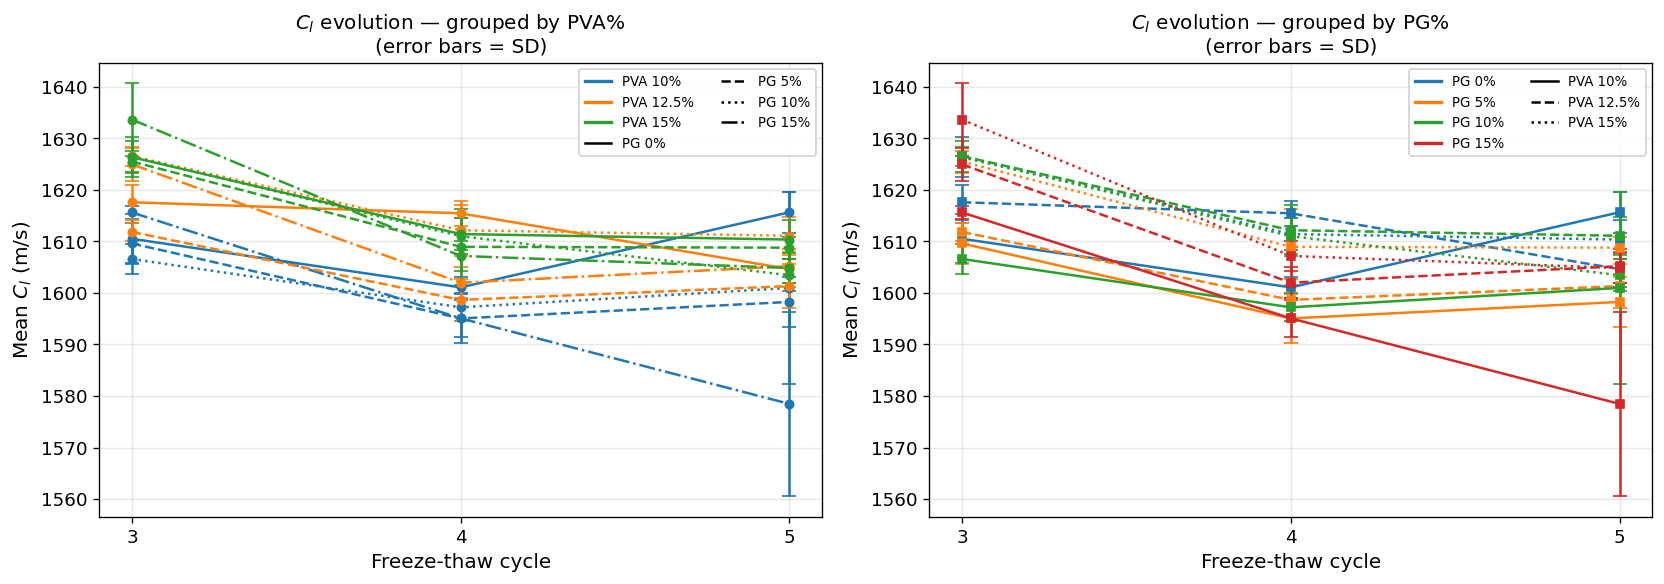

In [4]:
# --- Cell 2.1: Evolution of Cl by condition ---
grp_evol = df.groupby(['pva_real', 'pg_pct', 'cycle'])['US_Cl'].agg(
    mean='mean', std='std', n='count'
).reset_index()

xticks = [int(c) for c in sorted_cycles]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: grouped by PVA (color), PG = linestyle ---
for pva in PVA_LEVELS:
    for pg in PG_LEVELS:
        sub = grp_evol[(grp_evol['pva_real'] == pva) & (grp_evol['pg_pct'] == pg)].sort_values('cycle')
        if sub.empty:
            continue
        ax1.errorbar(sub['cycle'], sub['mean'], yerr=sub['std'],
                     color=PVA_COLOR[pva], linestyle=PG_LINESTYLE[pg],
                     marker='o', markersize=5, capsize=4, linewidth=1.5,
                     label=f'PVA {pva:.4g}% PG {int(pg)}%')

ax1.set_xticks(xticks)
ax1.set_xlabel('Freeze-thaw cycle', fontsize=12)
ax1.set_ylabel('Mean $C_l$ (m/s)', fontsize=12)
ax1.set_title('$C_l$ evolution — grouped by PVA%\n(error bars = SD)', fontsize=12)
pva_hdl = [mlines.Line2D([], [], color=PVA_COLOR[v], linewidth=2, label=f'PVA {v:.4g}%') for v in PVA_LEVELS]
pg_hdl  = [mlines.Line2D([], [], color='k', linestyle=PG_LINESTYLE[v], linewidth=1.5, label=f'PG {int(v)}%') for v in PG_LEVELS]
ax1.legend(handles=pva_hdl + pg_hdl, fontsize=8, ncol=2, framealpha=0.9)

# --- Right: grouped by PG (color), PVA = linestyle ---
for pg in PG_LEVELS:
    for pva in PVA_LEVELS:
        sub = grp_evol[(grp_evol['pva_real'] == pva) & (grp_evol['pg_pct'] == pg)].sort_values('cycle')
        if sub.empty:
            continue
        ax2.errorbar(sub['cycle'], sub['mean'], yerr=sub['std'],
                     color=PG_COLOR[pg], linestyle=PVA_LINESTYLE[pva],
                     marker='s', markersize=5, capsize=4, linewidth=1.5,
                     label=f'PVA {pva:.4g}% PG {int(pg)}%')

ax2.set_xticks(xticks)
ax2.set_xlabel('Freeze-thaw cycle', fontsize=12)
ax2.set_ylabel('Mean $C_l$ (m/s)', fontsize=12)
ax2.set_title('$C_l$ evolution — grouped by PG%\n(error bars = SD)', fontsize=12)
pg_hdl2  = [mlines.Line2D([], [], color=PG_COLOR[v],  linewidth=2, label=f'PG {int(v)}%') for v in PG_LEVELS]
pva_hdl2 = [mlines.Line2D([], [], color='k', linestyle=PVA_LINESTYLE[v], linewidth=1.5, label=f'PVA {v:.4g}%') for v in PVA_LEVELS]
ax2.legend(handles=pg_hdl2 + pva_hdl2, fontsize=8, ncol=2, framealpha=0.9)

plt.tight_layout()
plt.savefig(fig_dir / 'B2_01_evolution_Cl.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 2.2 — Evolution of density by condition

Same layout as 2.1 for density. Density increase can indicate water loss or polymer
densification; decrease indicates water absorption or structural degradation.
Compare trend direction with $C_l$: if both increase, the $C_l$ rise may be partly
explained by densification rather than stiffening alone.

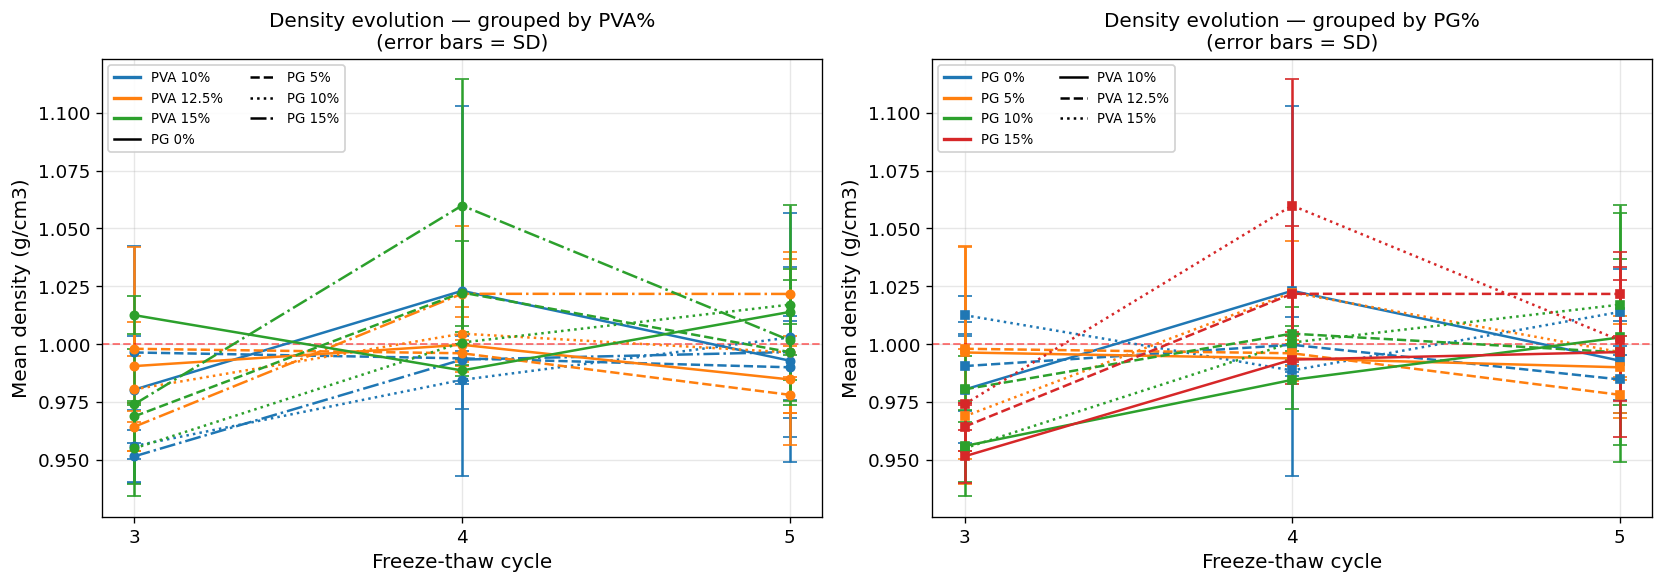

In [5]:
# --- Cell 2.2: Evolution of density by condition ---
grp_dens_evol = df.groupby(['pva_real', 'pg_pct', 'cycle'])['DENS_density_gcm3'].agg(
    mean='mean', std='std', n='count'
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for pva in PVA_LEVELS:
    for pg in PG_LEVELS:
        sub = grp_dens_evol[(grp_dens_evol['pva_real'] == pva) & (grp_dens_evol['pg_pct'] == pg)].sort_values('cycle')
        if sub.empty:
            continue
        ax1.errorbar(sub['cycle'], sub['mean'], yerr=sub['std'],
                     color=PVA_COLOR[pva], linestyle=PG_LINESTYLE[pg],
                     marker='o', markersize=5, capsize=4, linewidth=1.5)

ax1.axhline(1.0, color='red', linestyle='--', alpha=0.5, linewidth=1.2, label='rho=1.0 lower bound')
ax1.set_xticks(xticks)
ax1.set_xlabel('Freeze-thaw cycle', fontsize=12)
ax1.set_ylabel('Mean density (g/cm3)', fontsize=12)
ax1.set_title('Density evolution — grouped by PVA%\n(error bars = SD)', fontsize=12)
pva_hdl = [mlines.Line2D([], [], color=PVA_COLOR[v], linewidth=2, label=f'PVA {v:.4g}%') for v in PVA_LEVELS]
pg_hdl  = [mlines.Line2D([], [], color='k', linestyle=PG_LINESTYLE[v], linewidth=1.5, label=f'PG {int(v)}%') for v in PG_LEVELS]
ax1.legend(handles=pva_hdl + pg_hdl, fontsize=8, ncol=2, framealpha=0.9)

for pg in PG_LEVELS:
    for pva in PVA_LEVELS:
        sub = grp_dens_evol[(grp_dens_evol['pva_real'] == pva) & (grp_dens_evol['pg_pct'] == pg)].sort_values('cycle')
        if sub.empty:
            continue
        ax2.errorbar(sub['cycle'], sub['mean'], yerr=sub['std'],
                     color=PG_COLOR[pg], linestyle=PVA_LINESTYLE[pva],
                     marker='s', markersize=5, capsize=4, linewidth=1.5)

ax2.axhline(1.0, color='red', linestyle='--', alpha=0.5, linewidth=1.2, label='rho=1.0 lower bound')
ax2.set_xticks(xticks)
ax2.set_xlabel('Freeze-thaw cycle', fontsize=12)
ax2.set_ylabel('Mean density (g/cm3)', fontsize=12)
ax2.set_title('Density evolution — grouped by PG%\n(error bars = SD)', fontsize=12)
pg_hdl2  = [mlines.Line2D([], [], color=PG_COLOR[v],  linewidth=2, label=f'PG {int(v)}%') for v in PG_LEVELS]
pva_hdl2 = [mlines.Line2D([], [], color='k', linestyle=PVA_LINESTYLE[v], linewidth=1.5, label=f'PVA {v:.4g}%') for v in PVA_LEVELS]
ax2.legend(handles=pg_hdl2 + pva_hdl2, fontsize=8, ncol=2, framealpha=0.9)

plt.tight_layout()
plt.savefig(fig_dir / 'B2_02_evolution_density.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 2.3 — Evolution of thickness by condition

Thickness changes indicate swelling (increase) or contraction (decrease).
If a phantom shrinks, its density increases even without compositional change —
helping to separate structural effects from density artifacts.

**Red flag:** changes > 5% question the assumption of uniform cross-section in
the US measurement.

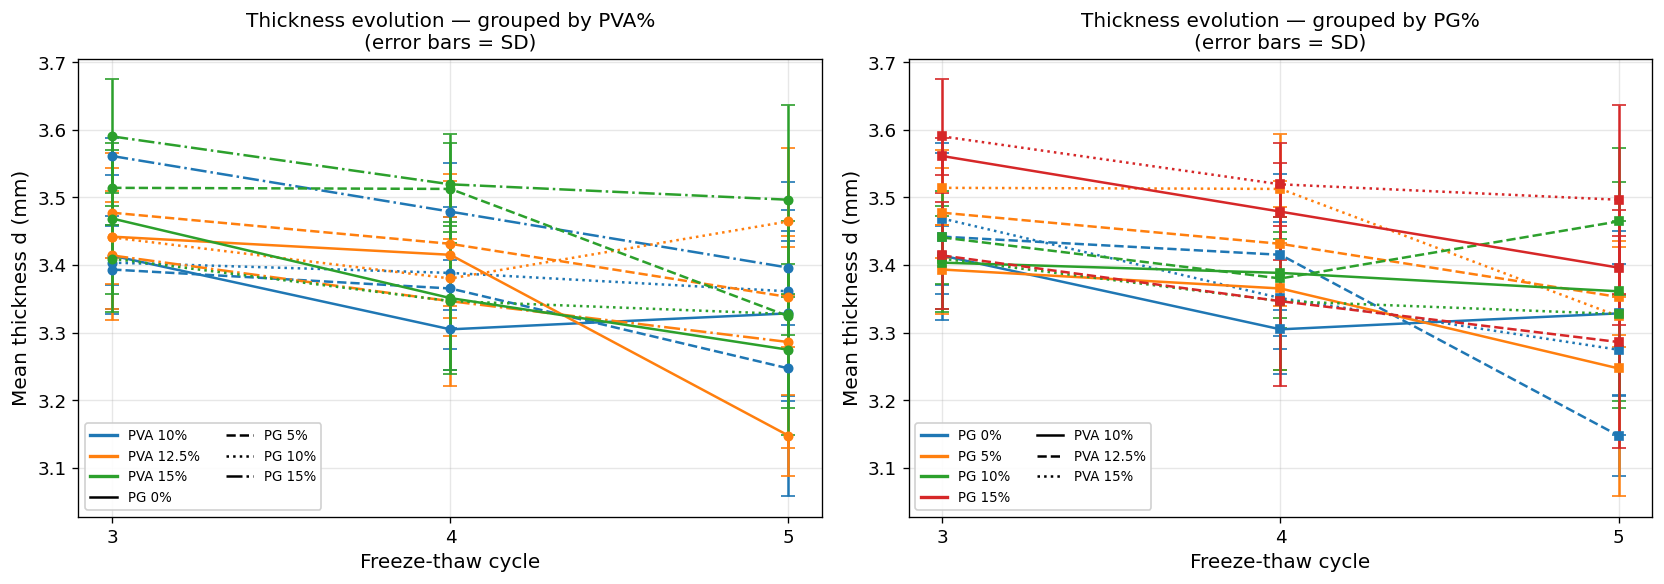

[!] PVA 12.5% PG 0%: thickness change = -8.5% (>5%)
[!] PVA 15.0% PG 0%: thickness change = -5.6% (>5%)
[!] PVA 15.0% PG 5%: thickness change = -5.4% (>5%)


In [6]:
# --- Cell 2.3: Evolution of thickness (US_d) by condition ---
if 'US_d' not in df.columns or df['US_d'].notna().sum() == 0:
    print('US_d not available in catalog — skipping Cell 2.3.')
else:
    grp_d_evol = df.groupby(['pva_real', 'pg_pct', 'cycle'])['US_d'].agg(
        mean='mean', std='std', n='count'
    ).reset_index()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for pva in PVA_LEVELS:
        for pg in PG_LEVELS:
            sub = grp_d_evol[(grp_d_evol['pva_real'] == pva) & (grp_d_evol['pg_pct'] == pg)].sort_values('cycle')
            if sub.empty or sub['n'].sum() == 0:
                continue
            ax1.errorbar(sub['cycle'], sub['mean'] * 1e3, yerr=sub['std'] * 1e3,
                         color=PVA_COLOR[pva], linestyle=PG_LINESTYLE[pg],
                         marker='o', markersize=5, capsize=4, linewidth=1.5)

    ax1.set_xticks(xticks)
    ax1.set_xlabel('Freeze-thaw cycle', fontsize=12)
    ax1.set_ylabel('Mean thickness d (mm)', fontsize=12)
    ax1.set_title('Thickness evolution — grouped by PVA%\n(error bars = SD)', fontsize=12)
    pva_hdl = [mlines.Line2D([], [], color=PVA_COLOR[v], linewidth=2, label=f'PVA {v:.4g}%') for v in PVA_LEVELS]
    pg_hdl  = [mlines.Line2D([], [], color='k', linestyle=PG_LINESTYLE[v], linewidth=1.5, label=f'PG {int(v)}%') for v in PG_LEVELS]
    ax1.legend(handles=pva_hdl + pg_hdl, fontsize=8, ncol=2, framealpha=0.9)

    for pg in PG_LEVELS:
        for pva in PVA_LEVELS:
            sub = grp_d_evol[(grp_d_evol['pva_real'] == pva) & (grp_d_evol['pg_pct'] == pg)].sort_values('cycle')
            if sub.empty or sub['n'].sum() == 0:
                continue
            ax2.errorbar(sub['cycle'], sub['mean'] * 1e3, yerr=sub['std'] * 1e3,
                         color=PG_COLOR[pg], linestyle=PVA_LINESTYLE[pva],
                         marker='s', markersize=5, capsize=4, linewidth=1.5)

    ax2.set_xticks(xticks)
    ax2.set_xlabel('Freeze-thaw cycle', fontsize=12)
    ax2.set_ylabel('Mean thickness d (mm)', fontsize=12)
    ax2.set_title('Thickness evolution — grouped by PG%\n(error bars = SD)', fontsize=12)
    pg_hdl2  = [mlines.Line2D([], [], color=PG_COLOR[v],  linewidth=2, label=f'PG {int(v)}%') for v in PG_LEVELS]
    pva_hdl2 = [mlines.Line2D([], [], color='k', linestyle=PVA_LINESTYLE[v], linewidth=1.5, label=f'PVA {v:.4g}%') for v in PVA_LEVELS]
    ax2.legend(handles=pg_hdl2 + pva_hdl2, fontsize=8, ncol=2, framealpha=0.9)

    plt.tight_layout()
    plt.savefig(fig_dir / 'B2_03_evolution_thickness.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Red flag: check for >5% change in any condition
    for (pva, pg), grp in grp_d_evol.groupby(['pva_real', 'pg_pct']):
        grp = grp.sort_values('cycle')
        if len(grp) >= 2:
            pct_change = (grp['mean'].iloc[-1] - grp['mean'].iloc[0]) / grp['mean'].iloc[0] * 100
            if abs(pct_change) > 5:
                print(f'[!] PVA {pva}% PG {int(pg)}%: thickness change = {pct_change:.1f}% (>5%)')


---
## Cell 2.4 — Paired differences $\Delta C_l$ between consecutive cycles

For each piece: $\Delta C_l = C_l(n+1) - C_l(n)$. Boxplots per condition with
individual points overlaid.

**Pedagogical note:** paired analysis eliminates inter-specimen variability.
If piece A is always 20 m/s faster than piece B (fabrication variability), that
difference cancels in $\Delta C_l$. What remains is the pure cycle effect.

**How to read:** box entirely above 0 = $C_l$ consistently increases.
Box shrinking toward 0 across transitions = convergence.

C:\Users\alrom\AppData\Local\Temp\ipykernel_20516\2665157310.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_dcl, labels=labels_cond, patch_artist=True,
C:\Users\alrom\AppData\Local\Temp\ipykernel_20516\2665157310.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_dcl, labels=labels_cond, patch_artist=True,


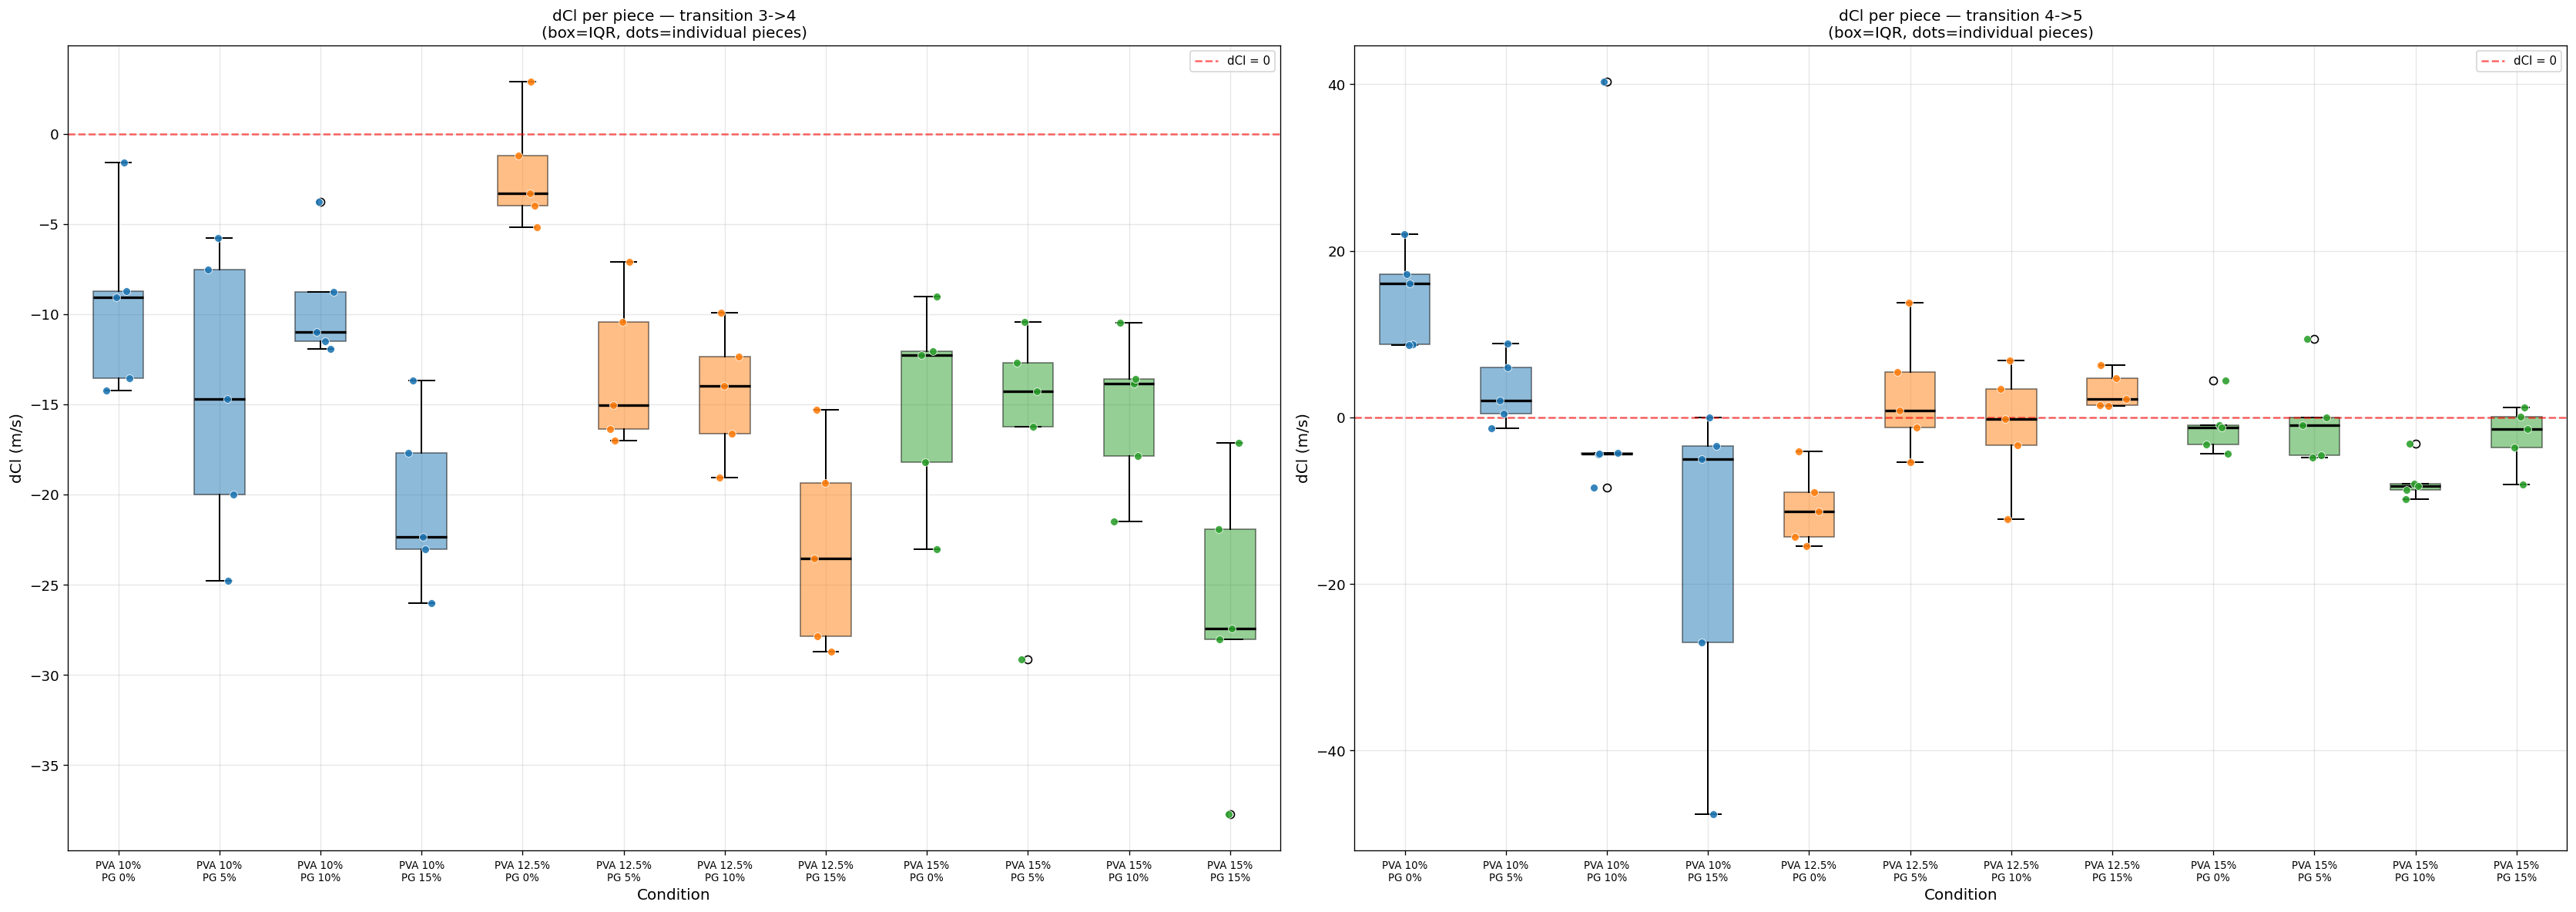


Mean dCl per condition per transition:


n    mean     std
pva_real pg_pct transition                   
10.0     0      3->4        5  -9.432   5.059
                4->5        5  14.576   5.751
         5      3->4        5 -14.554   8.072
                4->5        5   3.208   4.188
         10     3->4        5  -9.382   3.378
                4->5        5   3.768  20.504
         15     3->4        5 -20.548   4.875
                4->5        5 -16.596  20.364
12.5     0      3->4        5  -2.150   3.166
                4->5        5 -10.830   4.536
         5      3->4        5 -13.192   4.269
                4->5        5   2.692   7.327
         10     3->4        5 -14.378   3.573
                4->5        5  -1.084   7.277
         15     3->4        5 -22.952   5.672
                4->5        5   3.204   2.157
15.0     0      3->4        5 -14.910   5.627
                4->5        5  -1.066   3.411
         5      3->4        5 -16.544   7.353
                4->5        5  -0.162   5.792
         10     3->4        5 -15.450   4.276
                4->5        5  -7.580   2.558
         15     3->4        5 -26.450   7.708
                4->5        5  -2.346   3.664

In [9]:
# --- Cell 2.4: Boxplots of dCl per condition per transition ---
if df_delta_cl.empty:
    print('No transitions available — need at least 2 cycles.')
else:
    rng = np.random.default_rng(42)
    trans_list = sorted(df_delta_cl['transition'].unique())
    n_trans = len(trans_list)

    conditions = (
        df_delta_cl[['pva_real', 'pg_pct']]
        .drop_duplicates()
        .sort_values(['pva_real', 'pg_pct'])
        .reset_index(drop=True)
    )
    labels_cond = [f'PVA {r.pva_real:.4g}%\nPG {int(r.pg_pct)}%' for _, r in conditions.iterrows()]
    colors_box = [PVA_COLOR[r.pva_real] for _, r in conditions.iterrows()]

    fig, axes = plt.subplots(1, n_trans, figsize=(max(14, n_trans * 14), 10))
    if n_trans == 1:
        axes = [axes]

    for ax, trans in zip(axes, trans_list):
        sub_t = df_delta_cl[df_delta_cl['transition'] == trans]
        data_dcl = [
            sub_t[(sub_t['pva_real'] == r.pva_real) & (sub_t['pg_pct'] == r.pg_pct)]['dCl'].dropna().values
            for _, r in conditions.iterrows()
        ]
        bp = ax.boxplot(data_dcl, labels=labels_cond, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2},
                        whiskerprops={'linewidth': 1.2},
                        capprops={'linewidth': 1.2})

        for i, (patch, col) in enumerate(zip(bp['boxes'], colors_box)):
            patch.set_facecolor(col)
            patch.set_alpha(0.5)
            if len(data_dcl[i]) > 0:
                x_pts = rng.uniform(-0.15, 0.15, size=len(data_dcl[i])) + (i + 1)
                ax.scatter(x_pts, data_dcl[i], color=col, s=35, zorder=5,
                           edgecolors='white', linewidths=0.5, alpha=0.9)

        ax.axhline(0, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='dCl = 0')
        ax.set_xlabel('Condition', fontsize=12)
        ax.set_ylabel('dCl (m/s)', fontsize=12)
        ax.set_title(f'dCl per piece — transition {trans}\n(box=IQR, dots=individual pieces)', fontsize=12)
        ax.tick_params(axis='x', labelsize=8)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(fig_dir / 'B2_04_boxplot_dCl.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Quick stats per condition
    print('\nMean dCl per condition per transition:')
    stats_dcl = df_delta_cl.groupby(['pva_real', 'pg_pct', 'transition'])['dCl'].agg(
        n='count', mean='mean', std='std'
    ).round(3)
    display(stats_dcl)


---
## Cell 2.5 — Paired differences $\Delta$density between consecutive cycles

Same structure as 2.4 for density. Compare trend direction with $\Delta C_l$:
if both increase together, the $C_l$ rise may be partly due to densification.

C:\Users\alrom\AppData\Local\Temp\ipykernel_20516\1372663779.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_dd, labels=labels_cond, patch_artist=True,
C:\Users\alrom\AppData\Local\Temp\ipykernel_20516\1372663779.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_dd, labels=labels_cond, patch_artist=True,


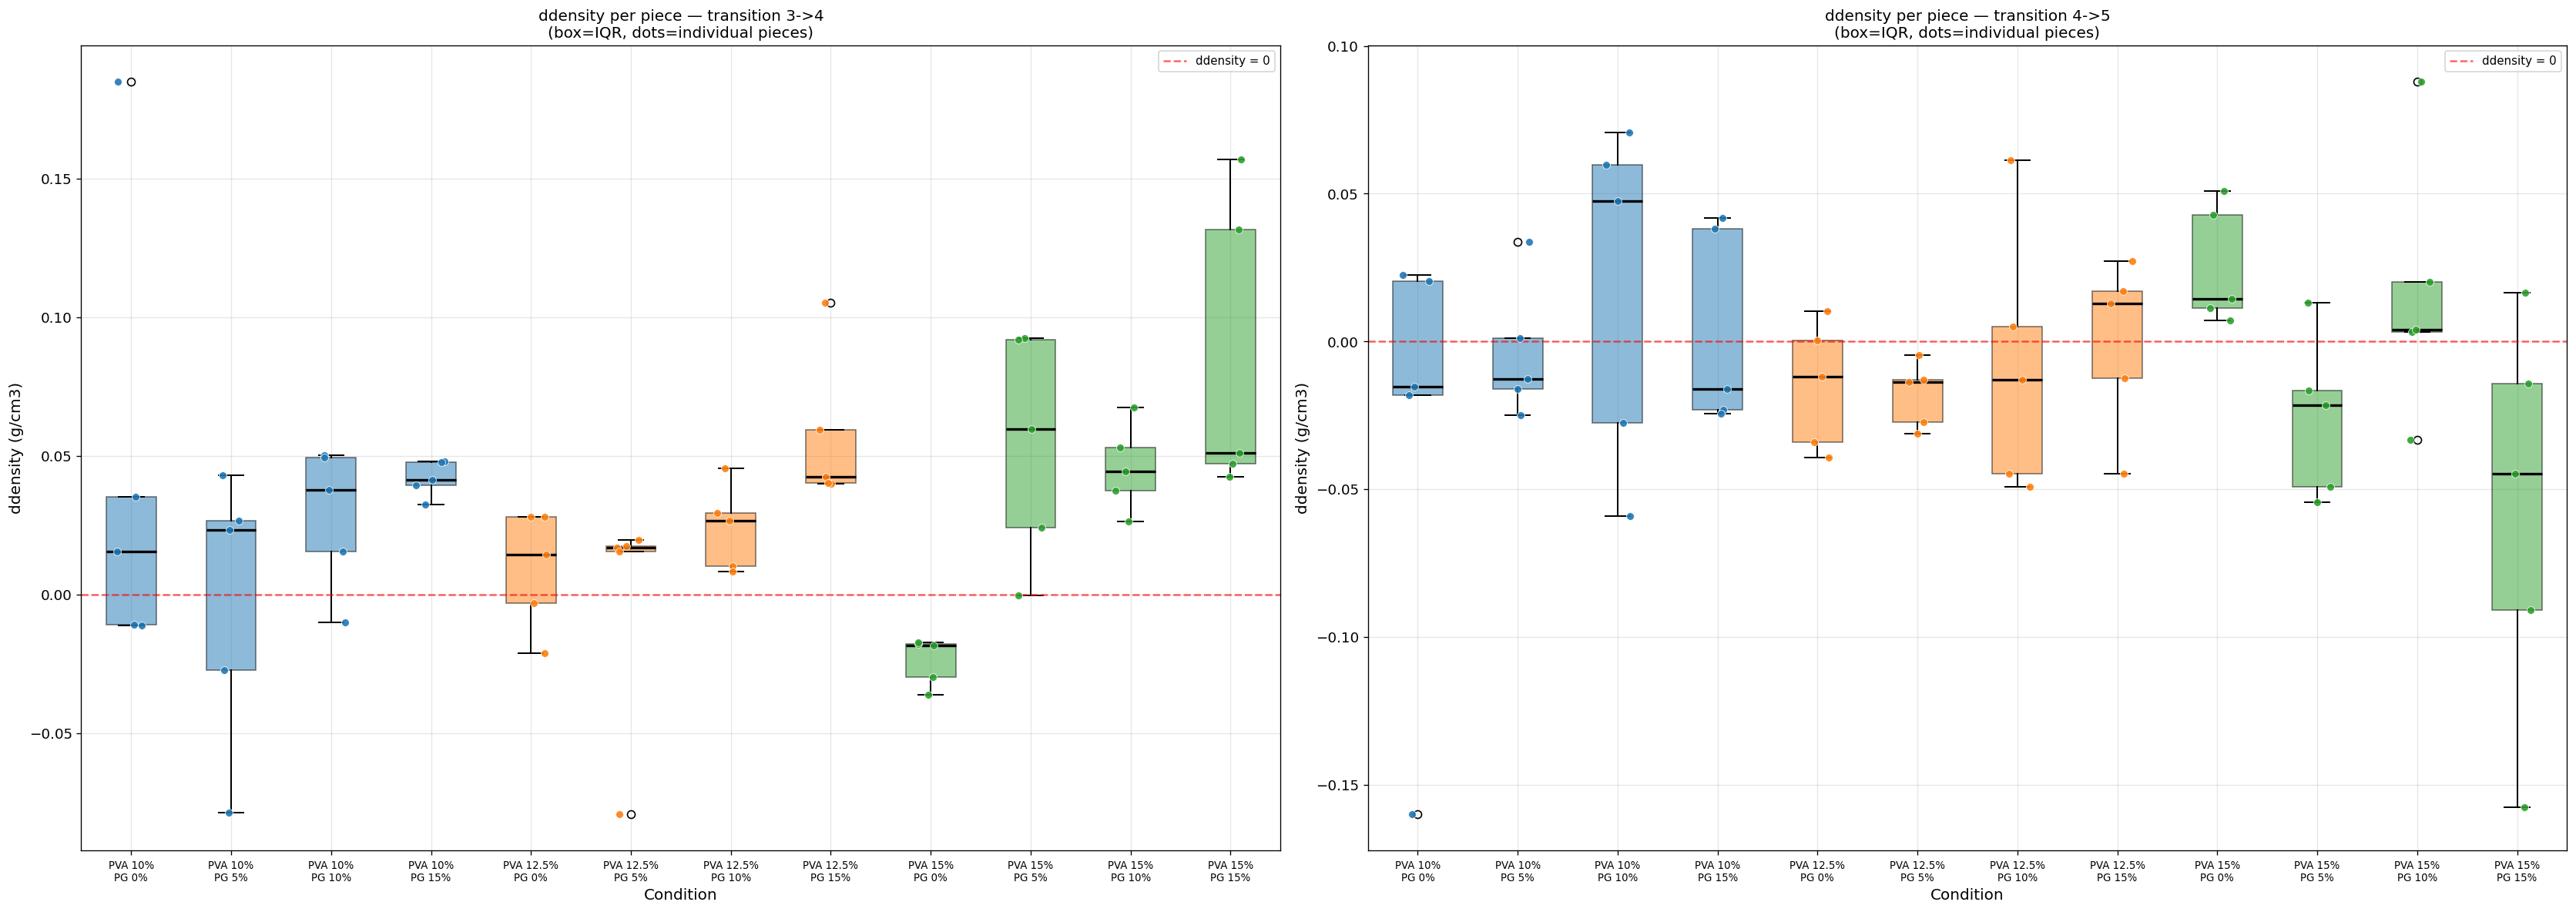

In [11]:
# --- Cell 2.5: Boxplots of delta_density per condition per transition ---
if df_delta_dens.empty:
    print('No transitions available.')
else:
    rng2 = np.random.default_rng(43)
    trans_list_d = sorted(df_delta_dens['transition'].unique())
    n_trans_d = len(trans_list_d)

    fig, axes = plt.subplots(1, n_trans_d, figsize=(max(14, n_trans_d * 14), 10))
    if n_trans_d == 1:
        axes = [axes]

    for ax, trans in zip(axes, trans_list_d):
        sub_t = df_delta_dens[df_delta_dens['transition'] == trans]
        data_dd = [
            sub_t[(sub_t['pva_real'] == r.pva_real) & (sub_t['pg_pct'] == r.pg_pct)]['ddensity'].dropna().values
            for _, r in conditions.iterrows()
        ]
        bp = ax.boxplot(data_dd, labels=labels_cond, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2},
                        whiskerprops={'linewidth': 1.2},
                        capprops={'linewidth': 1.2})

        for i, (patch, col) in enumerate(zip(bp['boxes'], colors_box)):
            patch.set_facecolor(col)
            patch.set_alpha(0.5)
            if len(data_dd[i]) > 0:
                x_pts = rng2.uniform(-0.15, 0.15, size=len(data_dd[i])) + (i + 1)
                ax.scatter(x_pts, data_dd[i], color=col, s=35, zorder=5,
                           edgecolors='white', linewidths=0.5, alpha=0.9)

        ax.axhline(0, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='ddensity = 0')
        ax.set_xlabel('Condition', fontsize=12)
        ax.set_ylabel('ddensity (g/cm3)', fontsize=12)
        ax.set_title(f'ddensity per piece — transition {trans}\n(box=IQR, dots=individual pieces)', fontsize=12)
        ax.tick_params(axis='x', labelsize=8)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(fig_dir / 'B2_05_boxplot_ddensity.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Cell 2.6 — Convergence analysis: rate of change vs cycle

Mean |$\Delta C_l$| per condition vs cycle transition. If the phantom stabilizes,
this curve approaches zero. Decreasing = convergence; flat = no stabilization;
increasing = degradation or instability.

Also computes the convergence ratio $|\Delta C_l(n+1)| / |\Delta C_l(n)|$ when
there are 3+ cycles. Values < 1 indicate convergence.

> **Limitation:** with only 2 cycles there is one transition point per condition.
> This cell becomes informative from 3+ cycles onward.

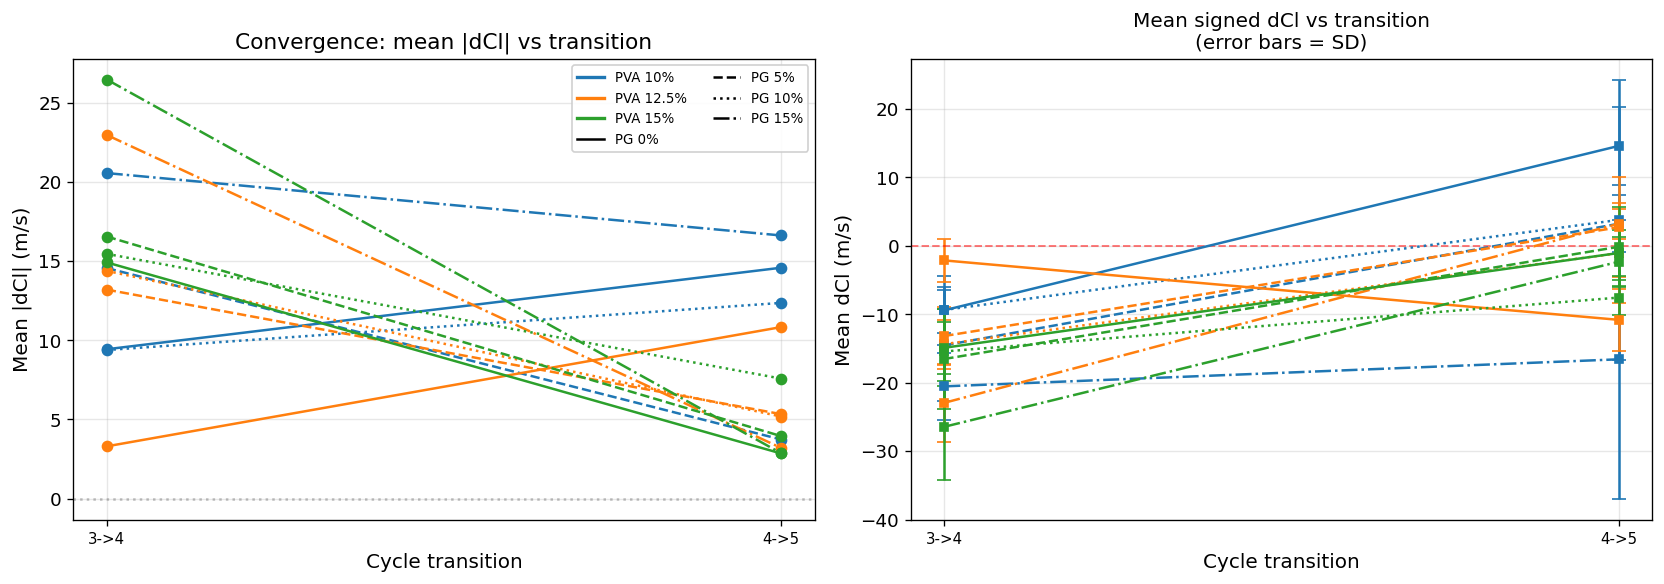

Convergence ratios |dCl(n+1)| / |dCl(n)| (< 1 = converging):
transition         3->4    4->5
pva_real pg_pct                
10.0     0        9.432  14.576
         5       14.554   3.736
         10       9.382  12.356
         15      20.548  16.612
12.5     0        3.306  10.830
         5       13.192   5.336
         10      14.378   5.184
         15      22.952   3.204
15.0     0       14.910   2.854
         5       16.544   3.950
         10      15.450   7.580
         15      26.450   2.870


In [12]:
# --- Cell 2.6: Convergence — mean |dCl| vs transition ---
if df_delta_cl.empty:
    print('No transitions available.')
else:
    # Mean absolute dCl per (condition, transition)
    conv = df_delta_cl.groupby(['pva_real', 'pg_pct', 'transition', 'c1', 'c2'])['dCl'].agg(
        mean_abs=lambda x: x.dropna().abs().mean(),
        mean_signed='mean',
        std='std',
        n='count'
    ).reset_index()

    trans_list_c = sorted(conv['transition'].unique())
    trans_x = list(range(1, len(trans_list_c) + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: mean |dCl| vs transition, one line per condition
    for pva in PVA_LEVELS:
        for pg in PG_LEVELS:
            sub = conv[(conv['pva_real'] == pva) & (conv['pg_pct'] == pg)].sort_values('c1')
            if sub.empty:
                continue
            x_pos = [trans_list_c.index(t) + 1 for t in sub['transition']]
            ax1.plot(x_pos, sub['mean_abs'],
                     color=PVA_COLOR[pva], linestyle=PG_LINESTYLE[pg],
                     marker='o', markersize=6, linewidth=1.5)

    ax1.axhline(0, color='grey', linestyle=':', alpha=0.5)
    ax1.set_xticks(trans_x)
    ax1.set_xticklabels(trans_list_c, fontsize=9)
    ax1.set_xlabel('Cycle transition', fontsize=12)
    ax1.set_ylabel('Mean |dCl| (m/s)', fontsize=12)
    ax1.set_title('Convergence: mean |dCl| vs transition', fontsize=13)
    pva_h = [mlines.Line2D([], [], color=PVA_COLOR[v], linewidth=2, label=f'PVA {v:.4g}%') for v in PVA_LEVELS]
    pg_h  = [mlines.Line2D([], [], color='k', linestyle=PG_LINESTYLE[v], linewidth=1.5, label=f'PG {int(v)}%') for v in PG_LEVELS]
    ax1.legend(handles=pva_h + pg_h, fontsize=8, ncol=2, framealpha=0.9)

    # Right: mean signed dCl (shows direction too)
    for pva in PVA_LEVELS:
        for pg in PG_LEVELS:
            sub = conv[(conv['pva_real'] == pva) & (conv['pg_pct'] == pg)].sort_values('c1')
            if sub.empty:
                continue
            x_pos = [trans_list_c.index(t) + 1 for t in sub['transition']]
            ax2.errorbar(x_pos, sub['mean_signed'], yerr=sub['std'],
                         color=PVA_COLOR[pva], linestyle=PG_LINESTYLE[pg],
                         marker='s', markersize=5, capsize=4, linewidth=1.5)

    ax2.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1.2)
    ax2.set_xticks(trans_x)
    ax2.set_xticklabels(trans_list_c, fontsize=9)
    ax2.set_xlabel('Cycle transition', fontsize=12)
    ax2.set_ylabel('Mean dCl (m/s)', fontsize=12)
    ax2.set_title('Mean signed dCl vs transition\n(error bars = SD)', fontsize=12)

    plt.tight_layout()
    plt.savefig(fig_dir / 'B2_06_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

    if len(trans_list_c) < 2:
        print('Only one transition available. Convergence ratio requires 3+ cycles.')
    else:
        print('Convergence ratios |dCl(n+1)| / |dCl(n)| (< 1 = converging):')
        print(conv.pivot_table(index=['pva_real', 'pg_pct'], columns='transition', values='mean_abs').round(3))


---
## Cell 2.7 — Interaction plot: cycle effect × composition

Left: mean $C_l$ vs cycle, one line per PVA% (averaged over PG%).
Right: mean $C_l$ vs cycle, one line per PG% (averaged over PVA%).

**Parallel lines** = no interaction (cycle effect independent of composition).
**Non-parallel lines** = interaction (some compositions respond more to cycling).
If interaction exists, per-cycle statements like "each cycle adds X m/s" are invalid —
the answer depends on composition.

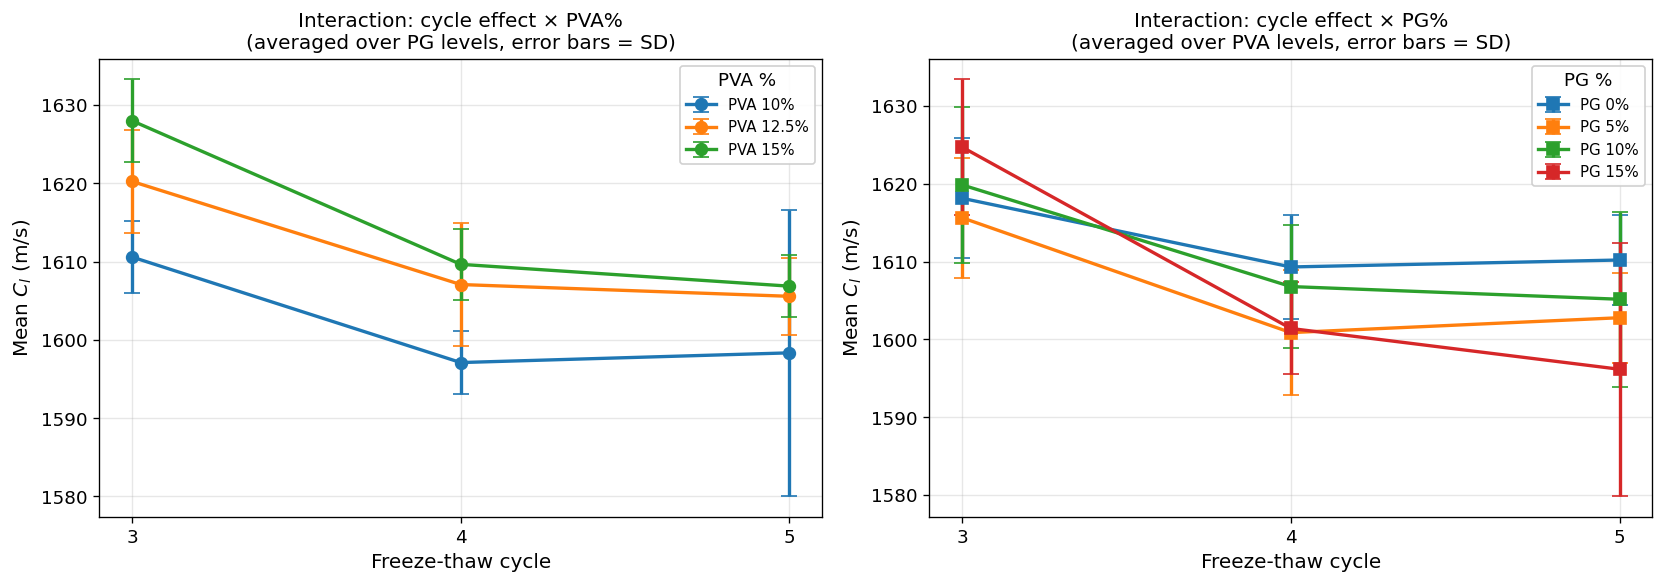


dCl (3->4) by PVA% (averaged over PG):
  PVA 10%: dCl = -13.48 m/s
  PVA 12.5%: dCl = -13.17 m/s
  PVA 15%: dCl = -18.34 m/s
dCl (3->4) by PG% (averaged over PVA):
  PG 0%: dCl = -8.83 m/s
  PG 5%: dCl = -14.76 m/s
  PG 10%: dCl = -13.07 m/s
  PG 15%: dCl = -23.32 m/s


In [13]:
# --- Cell 2.7: Interaction plots — cycle effect × composition ---
grp_pva_c = df.groupby(['pva_real', 'cycle'])['US_Cl'].agg(mean='mean', std='std').reset_index()
grp_pg_c  = df.groupby(['pg_pct',  'cycle'])['US_Cl'].agg(mean='mean', std='std').reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: lines = PVA levels (averaged over PG)
for pva in PVA_LEVELS:
    sub = grp_pva_c[grp_pva_c['pva_real'] == pva].sort_values('cycle')
    ax1.errorbar(sub['cycle'], sub['mean'], yerr=sub['std'],
                 color=PVA_COLOR[pva], marker='o', markersize=7,
                 capsize=5, linewidth=2.0, label=f'PVA {pva:.4g}%')

ax1.set_xticks(xticks)
ax1.set_xlabel('Freeze-thaw cycle', fontsize=12)
ax1.set_ylabel('Mean $C_l$ (m/s)', fontsize=12)
ax1.set_title('Interaction: cycle effect × PVA%\n(averaged over PG levels, error bars = SD)', fontsize=12)
ax1.legend(title='PVA %', fontsize=9, framealpha=0.9)

# Right: lines = PG levels (averaged over PVA)
for pg in PG_LEVELS:
    sub = grp_pg_c[grp_pg_c['pg_pct'] == pg].sort_values('cycle')
    ax2.errorbar(sub['cycle'], sub['mean'], yerr=sub['std'],
                 color=PG_COLOR[pg], marker='s', markersize=7,
                 capsize=5, linewidth=2.0, label=f'PG {int(pg)}%')

ax2.set_xticks(xticks)
ax2.set_xlabel('Freeze-thaw cycle', fontsize=12)
ax2.set_ylabel('Mean $C_l$ (m/s)', fontsize=12)
ax2.set_title('Interaction: cycle effect × PG%\n(averaged over PVA levels, error bars = SD)', fontsize=12)
ax2.legend(title='PG %', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(fig_dir / 'B2_07_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify parallelism: range of dCl per composition level
if len(transitions) >= 1:
    c1, c2 = transitions[0]
    print(f'\ndCl ({int(c1)}->{int(c2)}) by PVA% (averaged over PG):')
    for pva in PVA_LEVELS:
        sub = df[df['pva_real'] == pva]
        m1 = sub[sub['cycle'] == c1]['US_Cl'].mean()
        m2 = sub[sub['cycle'] == c2]['US_Cl'].mean()
        print(f'  PVA {pva:.4g}%: dCl = {m2 - m1:.2f} m/s')
    print(f'dCl ({int(c1)}->{int(c2)}) by PG% (averaged over PVA):')
    for pg in PG_LEVELS:
        sub = df[df['pg_pct'] == pg]
        m1 = sub[sub['cycle'] == c1]['US_Cl'].mean()
        m2 = sub[sub['cycle'] == c2]['US_Cl'].mean()
        print(f'  PG {int(pg)}%: dCl = {m2 - m1:.2f} m/s')


---
## Cell 2.8 — Repeated-measures statistical tests

For each condition and transition:
- **Paired t-test** (one-sample on $\Delta C_l$): H$_0$: mean $\Delta C_l = 0$
- **Wilcoxon signed-rank** (non-parametric backup): if normality violated
- **Cohen's d** (paired): $d = \text{mean}(\Delta C_l) / \text{SD}(\Delta C_l)$
- **Shapiro-Wilk** on $\Delta C_l$ values (more valid than testing raw data)

If parametric and non-parametric agree → report parametric.
If they disagree → report Wilcoxon and discuss (*Study Rules §5*).

> **Pedagogical note:** the paired t-test on $\Delta C_l$ is mathematically equivalent
> to a one-sample t-test testing $\Delta C_l = 0$. With n=5, p = 0.06 is *inconclusive*,
> not *no effect*. Always report Cohen's d alongside p-values.

In [14]:
# --- Cell 2.8: Paired statistical tests per condition ---
from scipy.stats import ttest_1samp, wilcoxon as wilcoxon_test

if df_delta_cl.empty:
    print('No transitions available.')
else:
    results_paired = []
    for (pva, pg), grp_cond in df_delta_cl.groupby(['pva_real', 'pg_pct']):
        for trans, grp_t in grp_cond.groupby('transition'):
            vals = grp_t['dCl'].dropna()
            n = len(vals)
            if n < 2:
                continue
            m   = vals.mean()
            s   = vals.std(ddof=1)
            d   = m / s if s != 0 else np.nan

            # Paired t-test (H0: mean dCl = 0)
            t_stat, p_t = ttest_1samp(vals, 0)

            # Wilcoxon signed-rank
            try:
                w_stat, p_w = wilcoxon_test(vals)
            except Exception:
                w_stat, p_w = np.nan, np.nan

            # Normality of differences (Shapiro-Wilk)
            W_sw, p_sw = (stats.shapiro(vals) if n >= 3 else (np.nan, np.nan))

            # Agreement between parametric and non-parametric
            agree = 'yes' if (pd.isna(p_w) or ((p_t < 0.05) == (p_w < 0.05))) else 'NO'

            # Effect size interpretation
            if pd.isna(d):
                eff = '-'
            elif abs(d) > 0.8:
                eff = 'large'
            elif abs(d) > 0.5:
                eff = 'medium'
            elif abs(d) > 0.2:
                eff = 'small'
            else:
                eff = 'negligible'

            results_paired.append({
                'PVA (%)':     pva,
                'PG (%)':      int(pg),
                'Transition':  trans,
                'n':           n,
                'mean dCl':    round(m, 2),
                'SD dCl':      round(s, 2),
                'Cohen d':     round(d, 2) if not pd.isna(d) else '-',
                'Effect':      eff,
                't':           round(t_stat, 3),
                'p (t-test)':  round(p_t, 4),
                'p (Wilcox)':  round(p_w, 4) if not pd.isna(p_w) else '-',
                'Shapiro p':   round(p_sw, 4) if not pd.isna(p_sw) else '-',
                'KP agree?':   agree,
                'Significant': 'yes' if p_t < 0.05 else 'no',
            })

    df_paired = pd.DataFrame(results_paired)
    print(f'Paired tests — dCl (H0: mean dCl = 0)\n')
    display(df_paired.set_index(['PVA (%)', 'PG (%)', 'Transition']))

    n_sig = (df_paired['Significant'] == 'yes').sum()
    print(f'\n{n_sig}/{len(df_paired)} conditions show significant cycle effect (p < 0.05, t-test).')
    disagree = df_paired[df_paired['KP agree?'] == 'NO']
    if not disagree.empty:
        print(f'[!] Parametric/non-parametric disagreement in {len(disagree)} case(s):')
        display(disagree[['PVA (%)', 'PG (%)', 'Transition', 'p (t-test)', 'p (Wilcox)', 'Shapiro p']])
        print('  -> Report Wilcoxon for these cases (Study Rules §5).')

    # Attempt repeated-measures ANOVA
    print('\n--- Repeated-measures ANOVA (requires pingouin) ---')
    try:
        import pingouin as pg_lib
        df_rm = df[['pva_real', 'pg_pct', 'piece', 'cycle', 'US_Cl']].dropna()
        df_rm['subject'] = df_rm['pva_real'].astype(str) + '_' + df_rm['pg_pct'].astype(str) + '_' + df_rm['piece']
        rm_result = pg_lib.rm_anova(data=df_rm, dv='US_Cl', within='cycle', subject='subject', detailed=True)
        display(rm_result)
    except ImportError:
        print('pingouin not installed. Install with: pip install pingouin')
        print('Manual Friedman test (non-parametric RM equivalent):')
        try:
            pieces_with_all = avail[avail.min(axis=1) > 0].reset_index()['piece'].unique()
            groups_by_cycle = [
                df[df['cycle'] == c]['US_Cl'].dropna().values
                for c in sorted_cycles
            ]
            if len(groups_by_cycle) >= 2 and all(len(g) >= 2 for g in groups_by_cycle):
                F_stat, p_fri = stats.friedmanchisquare(*groups_by_cycle)
                print(f'  Friedman chi2 = {F_stat:.3f}, p = {p_fri:.4f}')
        except Exception as e:
            print(f'  Could not run Friedman test: {e}')


Paired tests — dCl (H0: mean dCl = 0)



n  mean dCl  SD dCl  Cohen d      Effect      t  \
PVA (%) PG (%) Transition                                                    
10.0    0      3->4        5     -9.43    5.06    -1.86       large -4.169   
               4->5        5     14.58    5.75     2.53       large  5.668   
        5      3->4        5    -14.55    8.07    -1.80       large -4.032   
               4->5        5      3.21    4.19     0.77      medium  1.713   
        10     3->4        5     -9.38    3.38    -2.78       large -6.210   
               4->5        5      3.77   20.50     0.18  negligible  0.411   
        15     3->4        5    -20.55    4.87    -4.22       large -9.426   
               4->5        5    -16.60   20.36    -0.81       large -1.822   
12.5    0      3->4        5     -2.15    3.17    -0.68      medium -1.519   
               4->5        5    -10.83    4.54    -2.39       large -5.338   
        5      3->4        5    -13.19    4.27    -3.09       large -6.910   
               4->5        5      2.69    7.33     0.37       small  0.822   
        10     3->4        5    -14.38    3.57    -4.02       large -8.998   
               4->5        5     -1.08    7.28    -0.15  negligible -0.333   
        15     3->4        5    -22.95    5.67    -4.05       large -9.049   
               4->5        5      3.20    2.16     1.49       large  3.322   
15.0    0      3->4        5    -14.91    5.63    -2.65       large -5.925   
               4->5        5     -1.07    3.41    -0.31       small -0.699   
        5      3->4        5    -16.54    7.35    -2.25       large -5.031   
               4->5        5     -0.16    5.79    -0.03  negligible -0.063   
        10     3->4        5    -15.45    4.28    -3.61       large -8.079   
               4->5        5     -7.58    2.56    -2.96       large -6.627   
        15     3->4        5    -26.45    7.71    -3.43       large -7.673   
               4->5        5     -2.35    3.66    -0.64      medium -1.432   

                           p (t-test)  p (Wilcox)  Shapiro p KP agree?  \
PVA (%) PG (%) Transition                                                
10.0    0      3->4            0.0140      0.0625     0.3906        NO   
               4->5            0.0048      0.0625     0.3807        NO   
        5      3->4            0.0157      0.0625     0.6554        NO   
               4->5            0.1619      0.1875     0.7128       yes   
        10     3->4            0.0034      0.0625     0.1082        NO   
               4->5            0.7022      0.6250     0.0013       yes   
        15     3->4            0.0007      0.0625     0.7513        NO   
               4->5            0.1425      0.1250     0.1731       yes   
12.5    0      3->4            0.2035      0.1875     0.4502       yes   
               4->5            0.0059      0.0625     0.6973        NO   
        5      3->4            0.0023      0.0625     0.3178        NO   
               4->5            0.4575      0.6250     0.8045       yes   
        10     3->4            0.0008      0.0625     0.9740        NO   
               4->5            0.7558      1.0000     0.8028       yes   
        15     3->4            0.0008      0.0625     0.6071        NO   
               4->5            0.0293      0.0625     0.1962        NO   
15.0    0      3->4            0.0041      0.0625     0.5374        NO   
               4->5            0.5231      0.6250     0.3736       yes   
        5      3->4            0.0073      0.0625     0.1128        NO   
               4->5            0.9531      0.6250     0.1501       yes   
        10     3->4            0.0013      0.0625     0.7647        NO   
               4->5            0.0027      0.0625     0.0829        NO   
        15     3->4            0.0016      0.0625     0.8494        NO   
               4->5            0.2255      0.3125     0.5553       yes   

                          Significant  
PVA (%) PG (%) Transition        


15/24 conditions show significant cycle effect (p < 0.05, t-test).
[!] Parametric/non-parametric disagreement in 15 case(s):


,PVA (%),PG (%),Transition,p (t-test),p (Wilcox),Shapiro p
0,10.0,0,3->4,0.0140,0.0625,0.3906
1,10.0,0,4->5,0.0048,0.0625,0.3807
2,10.0,5,3->4,0.0157,0.0625,0.6554
4,10.0,10,3->4,0.0034,0.0625,0.1082
6,10.0,15,3->4,0.0007,0.0625,0.7513
9,12.5,0,4->5,0.0059,0.0625,0.6973
10,12.5,5,3->4,0.0023,0.0625,0.3178
12,12.5,10,3->4,0.0008,0.0625,0.9740
14,12.5,15,3->4,0.0008,0.0625,0.6071
15,12.5,15,4->5,0.0293,0.0625,0.1962


  -> Report Wilcoxon for these cases (Study Rules §5).

--- Repeated-measures ANOVA (requires pingouin) ---
pingouin not installed. Install with: pip install pingouin
Manual Friedman test (non-parametric RM equivalent):
  Friedman chi2 = 73.200, p = 0.0000


---
## Cell 2.9 — Correlation: $\Delta C_l$ vs $\Delta$density (paired)

Each point = one specimen. Positive correlation means $C_l$ and $\rho$ change together
(densification partly explains stiffening). No correlation means $C_l$ changes are
due to cross-linking independent of density change.

Transition 3->4: Pearson r = -0.2199, p = 0.0913
  Weak coupling: dCl is largely independent of density change.
Transition 4->5: Pearson r = -0.0995, p = 0.4493
  Weak coupling: dCl is largely independent of density change.


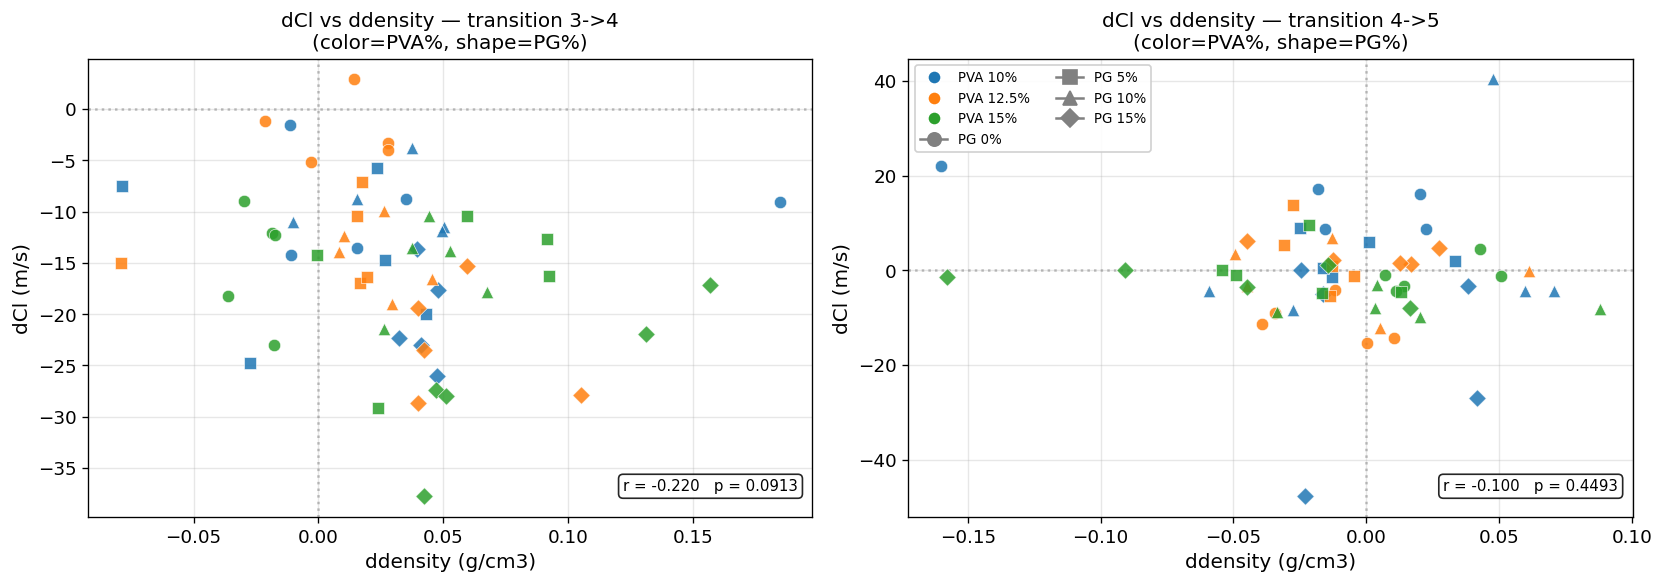

In [15]:
# --- Cell 2.9: dCl vs ddensity (paired scatter) ---
if df_delta_cl.empty or df_delta_dens.empty:
    print('No transitions available.')
else:
    merge_cols = ['pva_real', 'pg_pct', 'piece', 'transition']
    df_delta_merged = pd.merge(
        df_delta_cl[merge_cols + ['dCl']],
        df_delta_dens[merge_cols + ['ddensity']],
        on=merge_cols, how='inner'
    ).dropna(subset=['dCl', 'ddensity'])

    if df_delta_merged.empty:
        print('No matched dCl / ddensity pairs found.')
    else:
        trans_list_m = sorted(df_delta_merged['transition'].unique())
        n_trans_m = len(trans_list_m)
        fig, axes = plt.subplots(1, n_trans_m, figsize=(max(7, n_trans_m * 7), 5))
        if n_trans_m == 1:
            axes = [axes]

        for ax, trans in zip(axes, trans_list_m):
            sub_m = df_delta_merged[df_delta_merged['transition'] == trans]
            r_val, p_val = stats.pearsonr(sub_m['ddensity'], sub_m['dCl'])

            for pva in PVA_LEVELS:
                for pg in PG_LEVELS:
                    pts = sub_m[(sub_m['pva_real'] == pva) & (sub_m['pg_pct'] == pg)]
                    if pts.empty:
                        continue
                    ax.scatter(pts['ddensity'], pts['dCl'],
                               color=PVA_COLOR[pva], marker=PG_MARKER[pg],
                               s=55, alpha=0.85, edgecolors='white', linewidths=0.4, zorder=3)

            ax.axhline(0, color='grey', linestyle=':', alpha=0.5)
            ax.axvline(0, color='grey', linestyle=':', alpha=0.5)

            corr_str = f'r = {r_val:.3f}   p = {p_val:.4f}'
            ax.text(0.98, 0.05, corr_str, transform=ax.transAxes, fontsize=9,
                    ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

            ax.set_xlabel('ddensity (g/cm3)', fontsize=12)
            ax.set_ylabel('dCl (m/s)', fontsize=12)
            ax.set_title(f'dCl vs ddensity — transition {trans}\n(color=PVA%, shape=PG%)', fontsize=12)
            ax.grid(True, alpha=0.3)

            print(f'Transition {trans}: Pearson r = {r_val:.4f}, p = {p_val:.4f}')
            if abs(r_val) > 0.7:
                print('  Strong coupling: densification partly explains dCl.')
            elif abs(r_val) > 0.4:
                print('  Moderate coupling.')
            else:
                print('  Weak coupling: dCl is largely independent of density change.')

        pva_h = [mlines.Line2D([0],[0], marker='o', color='w', markerfacecolor=PVA_COLOR[v],
                                markersize=8, label=f'PVA {v:.4g}%') for v in PVA_LEVELS]
        pg_h  = [mlines.Line2D([0],[0], marker=PG_MARKER[v], color='grey',
                                markersize=8, label=f'PG {int(v)}%') for v in PG_LEVELS]
        axes[-1].legend(handles=pva_h + pg_h, fontsize=8, framealpha=0.9, ncol=2)

        plt.tight_layout()
        plt.savefig(fig_dir / 'B2_09_scatter_dCl_vs_ddensity.png', dpi=150, bbox_inches='tight')
        plt.show()


---
## Cell 2.10 — Spaghetti plot: individual piece trajectories

Unlike Cell 2.1 (means), this shows every piece's trajectory. Diagnostic plot:
reveals problems that means and SDs hide.

**Thin lines** = individual pieces ($\alpha = 0.5$). **Thick line** = condition mean.
Grid: 3 PVA × 4 PG = 12 panels.

**Parallel trajectories** = consistent behavior. **Crossing lines** = heterogeneous
response (fabrication defect, measurement error, real variability). One diverging piece
= investigate that specimen.

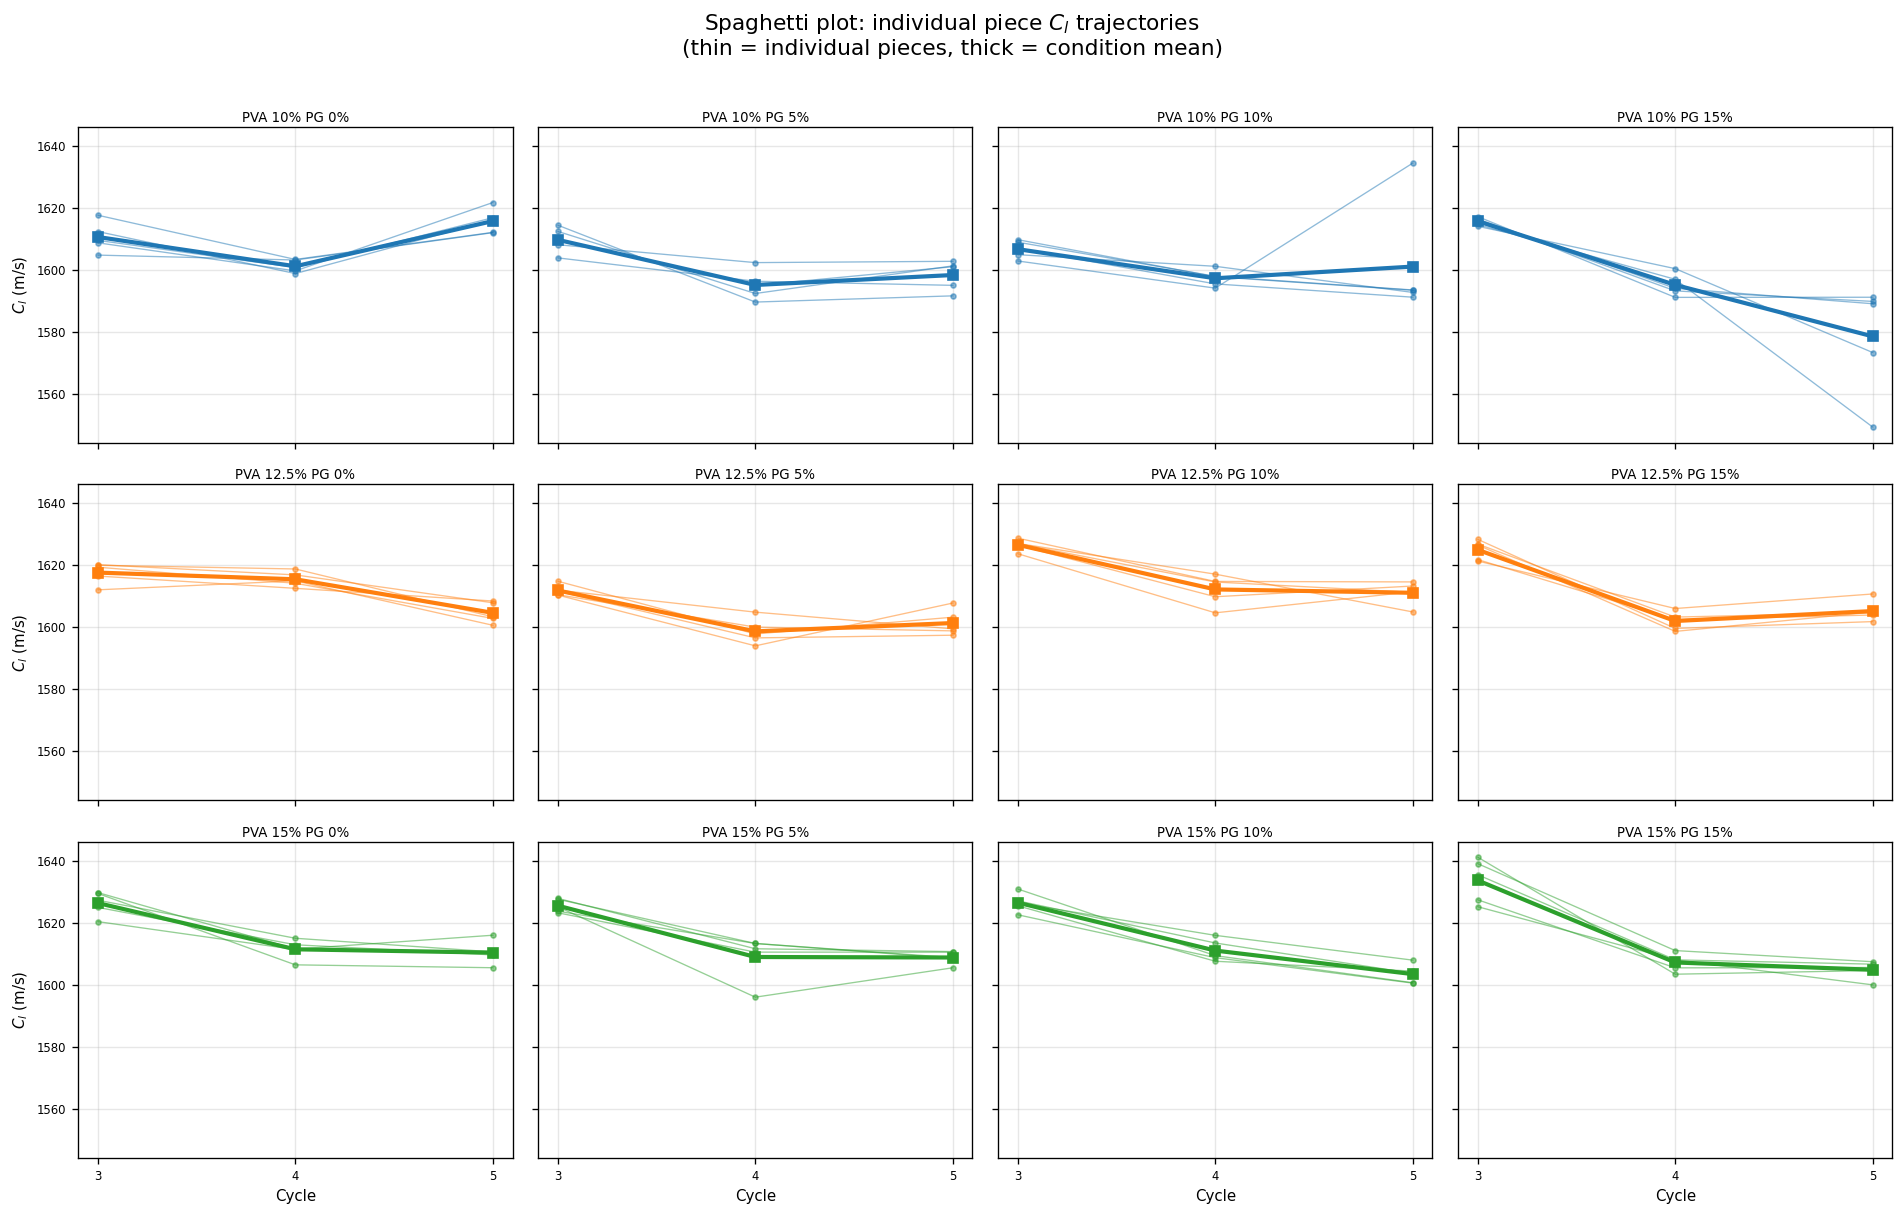

In [16]:
# --- Cell 2.10: Spaghetti plot — individual piece Cl trajectories ---
n_pva = len(PVA_LEVELS)
n_pg  = len(PG_LEVELS)

fig, axes = plt.subplots(n_pva, n_pg, figsize=(16, 10),
                          sharex=True, sharey=True)

pivot_cl_reset = pivot_cl.reset_index()
pivot_cl_reset.columns.name = None
cycle_cols = [c for c in pivot_cl_reset.columns if c not in ('pva_real', 'pg_pct', 'piece')]

cl_all = df['US_Cl'].dropna()
y_min = cl_all.min() - 5
y_max = cl_all.max() + 5

for i, pva in enumerate(PVA_LEVELS):
    for j, pg in enumerate(PG_LEVELS):
        ax = axes[i, j]
        col = PVA_COLOR[pva]

        # Individual piece trajectories
        sub_piv = pivot_cl_reset[
            (pivot_cl_reset['pva_real'] == pva) & (pivot_cl_reset['pg_pct'] == pg)
        ]
        for _, row in sub_piv.iterrows():
            y_vals = [row[c] if c in row.index and not pd.isna(row[c]) else np.nan for c in cycle_cols]
            ax.plot(cycle_cols, y_vals, 'o-', color=col,
                    linewidth=0.8, alpha=0.5, markersize=3)

        # Condition mean (thick line)
        df_sub = df[(df['pva_real'] == pva) & (df['pg_pct'] == pg)]
        mean_by_cycle = df_sub.groupby('cycle')['US_Cl'].mean().sort_index()
        ax.plot(mean_by_cycle.index, mean_by_cycle.values, 's-', color=col,
                linewidth=2.5, markersize=6, zorder=5, label='mean')

        ax.set_title(f'PVA {pva:.4g}% PG {int(pg)}%', fontsize=8, pad=3)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks([int(c) for c in sorted_cycles])
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

        if i == n_pva - 1:
            ax.set_xlabel('Cycle', fontsize=9)
        if j == 0:
            ax.set_ylabel('$C_l$ (m/s)', fontsize=9)

fig.suptitle('Spaghetti plot: individual piece $C_l$ trajectories\n'
             '(thin = individual pieces, thick = condition mean)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(fig_dir / 'B2_10_spaghetti_Cl.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 2.11 — Summary and interpretation

> **Instructions:** Fill in this template after running all cells above.
> Use the statistics and figures generated above to support each statement.
> Consult the checklist in *Study Rules §8* before writing conclusions.

---

### Block 2 — Summary

**Cycle effect on $C_l$:**
- Direction: *[increases / decreases / no consistent change]*
- Magnitude: mean $\Delta C_l$ = *[X]* ± *[Y]* m/s per cycle (range across conditions)
- Significant? *[yes/no, with test and exact p-value; note if KW agrees]*
- Effect size: Cohen's d = *[range across conditions]*
- Composition dependence: *[does dCl differ across PVA or PG levels? — from Cell 2.7]*

**Cycle effect on density:**
- Direction: *[increases / decreases / stable]*
- Magnitude: mean $\Delta\rho$ = *[X]* ± *[Y]* g/cm³ per cycle
- Comparison with $\Delta C_l$: *[same direction? coupled?]*

**Convergence:**
- Rate of change between cycles: *[increasing / decreasing / constant — from Cell 2.6]*
- Estimated cycles to stabilization: *[N or "not yet reached" or "insufficient data"]*

**Interaction with composition:**
- Does the cycle effect depend on PVA%? *[yes/no, evidence from Cell 2.7]*
- Does the cycle effect depend on PG%? *[yes/no]*
- If yes: *[describe which composition is most/least affected]*

**Correlation $\Delta C_l$ vs $\Delta\rho$ (Cell 2.9):**
- r = *[value]*, p = *[value]*
- Interpretation: *[coupled / independent — mechanism implication]*

**Individual trajectories (Cell 2.10):**
- Any outlier pieces? *[identify by condition and piece ID if yes]*
- Trajectories generally parallel? *[yes / no — implies consistent vs heterogeneous response]*

**Limitations:**
- Number of cycle transitions: *[N-1]*
- Cannot separate cycle effect from aging (time elapsed)
- Cannot separate cross-linking from water loss / PG migration
- *[Other limitations observed during analysis]*

---
*Hypotheses addressed: H3 (cycles increase $C_l$), H5 (convergence) — see Study Rules §1.*